# 复现 walkthrough（bear 数据集）

本 notebook 与 `reproduce_walkthrough.ipynb`（umineko 数据集）、
`reproduce_walkthrough_turtle.ipynb`（turtle 数据集）结构完全一致，
但目标换成 **bear 数据集**，并**保留每一步的中间结果**：数据形状、标签分布、
数据切分、模型结构、20 轮主动学习的逐轮指标、指标曲线，以及 UMAP / 标签传播 /
时序标签等可视化。

bear 与 umineko / turtle 的差异：
- 数据 `(N, 3, 50)`：仅 3 轴加速度（无气压通道），窗口长度 50（turtle 为 200，
  与 umineko 的 50 相同）。
- 10 个行为类别（0..9）：dig / eat / groom / head_shake / pounce / rest / roll /
  run / swim / walk。数据**全部带标签**（无 -1 unknown），类别高度不均衡
  （rest 占 ~77%）。

代码复用 `reproduce/` 下的 bear 模块（`bear_data` / `bear_model`）与通用的
`train_eval`。

## 0. 环境与随机种子

In [ ]:
import os, sys, random, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

HERE = os.path.abspath('.')
sys.path.insert(0, HERE)

from bear_data import (load_data, build_splits, data_loader_bear,
                       labeldict_findstr, label_colors,
                       labeldict_wounknown_findstr, NUM_CLASSES)
from bear_model import BearNN, SupContrastiveLoss, freeze_encoders
from data_preprocessing import majority_value
from train_eval import (train_model, evaluate_model, evaluate_supContrast_model,
                        unfreeze_encoders, unfreeze_all,
                        uncertainty_sampling, AE_eval_time_series)

def set_random_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def get_device():
    # GPU 优先：CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

SEED = 2025
set_random_seed(SEED)
device = get_device()
print('torch', torch.__version__, '| device', device, '| seed', SEED)

## 1. 数据读取与预处理

加载 `data/bear/data.npy` 与 `label.npy`，对每个窗口的逐帧标签做多数投票
（bear 无 foraging 重映射；数据全部带标签，无 unknown）。

In [2]:
DATA = os.path.normpath(os.path.join(HERE, '..', 'data', 'bear', 'data.npy'))
LABEL = os.path.normpath(os.path.join(HERE, '..', 'data', 'bear', 'label.npy'))
data_b, label_b, vote_label = load_data(DATA, LABEL)
print('data_b :', data_b.shape, data_b.dtype, '  (N, channels=3accel, win_len=50)')
print('label_b:', label_b.shape, '  (per-timestep labels)')
print('vote_label:', vote_label.shape)

data_b : (225915, 3, 50) float64   (N, channels=3accel, win_len=50)
label_b: (225915, 50)   (per-timestep labels)
vote_label: (225915,)


In [3]:
# 投票后标签分布
uniq, cnt = np.unique(vote_label, return_counts=True)
dist = pd.DataFrame({'label': uniq,
                     'name': [labeldict_findstr.get(int(u), str(u)) for u in uniq],
                     'count': cnt})
dist

,label,name,count
0,0,dig,1668
1,1,eat,5492
2,2,groom,1488
3,3,head_shake,969
4,4,pounce,141
5,5,rest,174223
6,6,roll,2138
7,7,run,823
8,8,swim,1399
9,9,walk,37574


### 1.1 训练/测试切分 + labeled/unlabeled 切分

In [4]:
splits = build_splits(data_b, vote_label)
X_labeled, y_labeled   = splits['X_labeled'],   splits['y_labeled']
X_unlabeled, y_unlabeled = splits['X_unlabeled'], splits['y_unlabeled']
X_test, y_test         = splits['X_test'],      splits['y_test']
X_train_full           = splits['X_train_full']

print('X_labeled  :', X_labeled.shape)
print('X_unlabeled:', X_unlabeled.shape)
print('X_test     :', X_test.shape)

X_labeled  : (1807, 3, 50)
X_unlabeled: (178925, 3, 50)
X_test     : (45183, 3, 50)


In [5]:
# 初始 labeled 集合的类别分布
u, c = np.unique(y_labeled, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr[int(i)] for i in u], 'count': c})

,label,name,count
0,0,dig,17
1,1,eat,33
2,2,groom,21
3,3,head_shake,8
4,4,pounce,4
5,5,rest,1369
6,6,roll,24
7,7,run,5
8,8,swim,9
9,9,walk,317


## 2. 模型

`BearNN`：3 轴加速度走单个 `Encoder3d4`，窗口 50 经三次 /2 池化得到 6，
特征维 128*6=768；Linear 到 32 维共享嵌入；再分出 projector(对比学习 16 维)
与 classifier(10 类)。

In [6]:
model = BearNN(number_classes=NUM_CLASSES).to(device)
classify_criterion = nn.CrossEntropyLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {n_params:,}')
print(model)

总参数量: 152,058
BearNN(
  (acc_encoder): Encoder3d4(
    (conv1): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc): Linear(in_features=768, out_features=64, bias=True)
  )
  (linear): Linear(in_features=768, out_features=32, bias=True)
  (projector): Sequential(
    (0): Linear(in_features=32, 

In [ ]:
# 单次前向，确认各阶段张量形状
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_labeled[:4]).float().to(device)
    proj_out, feat32 = model(sample, if_contrast=True)
    clf_out, _       = model(sample, if_contrast=False)
print('共享32维特征 :', tuple(feat32.shape))
print('projector输出 :', tuple(proj_out.shape))
print('classifier输出:', tuple(clf_out.shape), '(logits over 10类)')

## 3. 主动学习训练循环（20 轮）

每轮三阶段：①监督对比 warm-up（解冻编码器，10 epoch）②冻结编码器训练分类器（50 epoch）
③全解冻再训分类头（50 epoch）。随后在测试集评估，并用**熵不确定性采样**新增 1% 样本。

下方每轮都会打印训练/测试的 Accuracy、Macro-F1、Micro-F1（中间结果全部保留）。

> bear 数据集体量较大（labeled 集从 ~1800 增长到 ~36000）。已自动选择 GPU（CUDA/MPS）；
> 若无可用 GPU 则回退 CPU，在 CPU 上该循环耗时较长。

In [8]:
set_random_seed(SEED)  # 重置以保证可复现
model = BearNN(number_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

max_iter, warmup, batch_size = 20, 20, 4000
update_size = max(int(0.01 * len(X_train_full)), 2)

metrics, loss_list, selected_labels_list = [], [], []
weight_list = []
iteration = 1
while len(X_unlabeled) > 0:
    print(f'============== Iteration {iteration} ==============')
    print(f'labeled={len(X_labeled)}  unlabeled={len(X_unlabeled)}')

    labeled_loader = DataLoader(
        data_loader_bear(X_labeled.astype(float), y_labeled.astype(int)),
        batch_size=batch_size, shuffle=True, drop_last=False)

    # stage 1: supervised contrastive warm-up
    unfreeze_encoders(model)
    if iteration < warmup:
        model, _ = train_model(model, labeled_loader, supContrast_criterion,
                               optimizer, epochs=10, device=device, if_contrast=True)
    # stage 2: classifier-only
    freeze_encoders(model)
    model, _ = train_model(model, labeled_loader, classify_criterion,
                           optimizer, epochs=50, device=device, if_contrast=False)
    # stage 3: unfreeze all
    unfreeze_all(model)
    model, avg_loss = train_model(model, labeled_loader, classify_criterion,
                                  optimizer, epochs=50, device=device, if_contrast=False)
    loss_list.append(np.average(avg_loss))

    print('-- Train --')
    tr_acc, tr_macro, tr_micro, _, _ = evaluate_model(model, labeled_loader, device)
    test_loader = DataLoader(
        data_loader_bear(X_test.astype(float), y_test.astype(int)),
        batch_size=batch_size, shuffle=False, drop_last=False)
    print('-- Test --')
    te_acc, te_macro, te_micro, _, _, _ = evaluate_supContrast_model(
        model, test_loader, cal_threshold=0.5, device=device)

    metrics.append(dict(iteration=iteration, labeled_samples=len(X_labeled),
                        train_acc=tr_acc, train_macro_f1=tr_macro, train_micro_f1=tr_micro,
                        test_acc=te_acc, test_macro_f1=te_macro, test_micro_f1=te_micro))
    weight_list.append({k: v.clone() for k, v in model.state_dict().items()})

    select_size = min(update_size, len(X_unlabeled))
    X_labeled, y_labeled, X_unlabeled, y_unlabeled, sel = uncertainty_sampling(
        X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, select_size, device)
    selected_labels_list.append(sel)

    iteration += 1
    if iteration == max_iter + 1:
        break
print('训练循环完成')

============== Iteration 1 ==============
labeled=1807  unlabeled=178925


-- Train --


Accuracy: 0.96, Macro F1 Score: 0.59, Micro F1 Score: 0.96
-- Test --


Accuracy: 0.97, Macro F1 Score: 0.35, Micro F1 Score: 0.97


Labeled samples: 3614
============== Iteration 2 ==============
labeled=3614  unlabeled=177118


...

Labeled samples: 36140
============== Iteration 20 ==============
labeled=36140  unlabeled=144592


-- Train --


Accuracy: 0.99, Macro F1 Score: 0.98, Micro F1 Score: 0.99
-- Test --


Accuracy: 0.97, Macro F1 Score: 0.68, Micro F1 Score: 0.97


Labeled samples: 37947
训练循环完成


## 4. 逐轮指标汇总

In [9]:
df = pd.DataFrame(metrics)
df

,iteration,labeled_samples,train_acc,train_macro_f1,train_micro_f1,test_acc,test_macro_f1,test_micro_f1
0,1,1807,0.962922,0.593903,0.962922,0.974852,0.354623,0.974852
1,2,3614,0.859159,0.583179,0.859159,0.971320,0.497709,0.971320
2,3,5421,0.898727,0.854262,0.898727,0.973709,0.626429,0.973709
3,4,7228,0.921832,0.908963,0.921832,0.974829,0.668611,0.974829
4,5,9035,0.942999,0.943819,0.942999,0.974091,0.675671,0.974091
5,6,10842,0.970670,0.973346,0.970670,0.973446,0.699351,0.973446
6,7,12649,0.951617,0.945484,0.951617,0.970843,0.670213,0.970843
7,8,14456,0.998063,0.998127,0.998063,0.971002,0.696165,0.971002
8,9,16263,0.981430,0.971310,0.981430,0.970959,0.680410,0.970959
9,10,18070,0.996624,0.997050,0.996624,0.971361,0.687546,0.971361


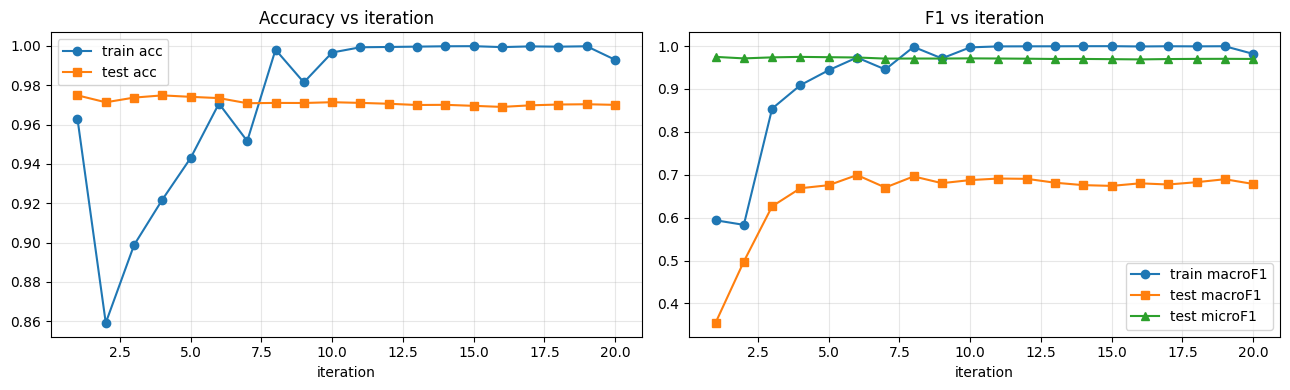

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df.iteration, df.train_acc, 'o-', label='train acc')
axes[0].plot(df.iteration, df.test_acc, 's-', label='test acc')
axes[0].set_title('Accuracy vs iteration'); axes[0].set_xlabel('iteration')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(df.iteration, df.train_macro_f1, 'o-', label='train macroF1')
axes[1].plot(df.iteration, df.test_macro_f1, 's-', label='test macroF1')
axes[1].plot(df.iteration, df.test_micro_f1, '^-', label='test microF1')
axes[1].set_title('F1 vs iteration'); axes[1].set_xlabel('iteration')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. 可视化中间结果

构造 combined 集合（labeled 窗口 + 录音切片 [6000:9000]，该区间覆盖全部 10 类），
过模型取 32 维特征，UMAP 投影到 2 维；再用 `LabelSpreading` 做标签传播。下面把
UMAP 散点（真值 / 预测 / 传播标签）直接画在 notebook 中。

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from umap import UMAP

startloc, endloc = 6000, 9000
combinedata = np.concatenate([X_labeled, data_b[startloc:endloc]])
combinelabel_true = np.concatenate([y_labeled, vote_label[startloc:endloc]])

loader = DataLoader(data_loader_bear(combinedata.astype(float), combinelabel_true.astype(int)),
                    batch_size=batch_size, shuffle=False, drop_last=False)
repres_list, _, pred_list, label_list = AE_eval_time_series(loader, model, device)

repre = np.concatenate(repres_list).reshape(len(combinedata), -1).astype(float)
proj = UMAP(n_components=2, random_state=SEED).fit_transform(repre)
all_labels = np.concatenate(label_list)
predictions = np.argmax(np.concatenate(pred_list), axis=1)
print('combined:', combinedata.shape, '| UMAP proj:', proj.shape)

/Users/cassie/Documents/code/DeepView/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/cassie/Documents/code/DeepView/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


combined: (40947, 3, 50) | UMAP proj: (40947, 2)


In [12]:
# 标签传播：把追加的录音切片标记为 -1(未知)，从已知 labeled 点扩散
combineunlabel = np.concatenate([y_labeled, np.full(vote_label[startloc:endloc].shape, -1)])
loader2 = DataLoader(data_loader_bear(combinedata.astype(float), combineunlabel.astype(int)),
                     batch_size=batch_size, shuffle=False, drop_last=False)
_, _, _, unlabel_list = AE_eval_time_series(loader2, model, device)
all_labels_before = np.concatenate(unlabel_list)

data_umap = StandardScaler().fit_transform(proj)
ls = LabelSpreading(kernel='knn', n_neighbors=10, alpha=0.2)
ls.fit(data_umap, all_labels_before)
propagated_labels = ls.transduction_
u, c = np.unique(propagated_labels, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr.get(int(i), str(i)) for i in u], 'count': c})

,label,name,count
0,0,dig,1349
1,1,eat,3542
2,2,groom,1101
3,3,head_shake,618
4,4,pounce,108
5,5,rest,26873
6,6,roll,1372
7,7,run,479
8,8,swim,1114
9,9,walk,4391


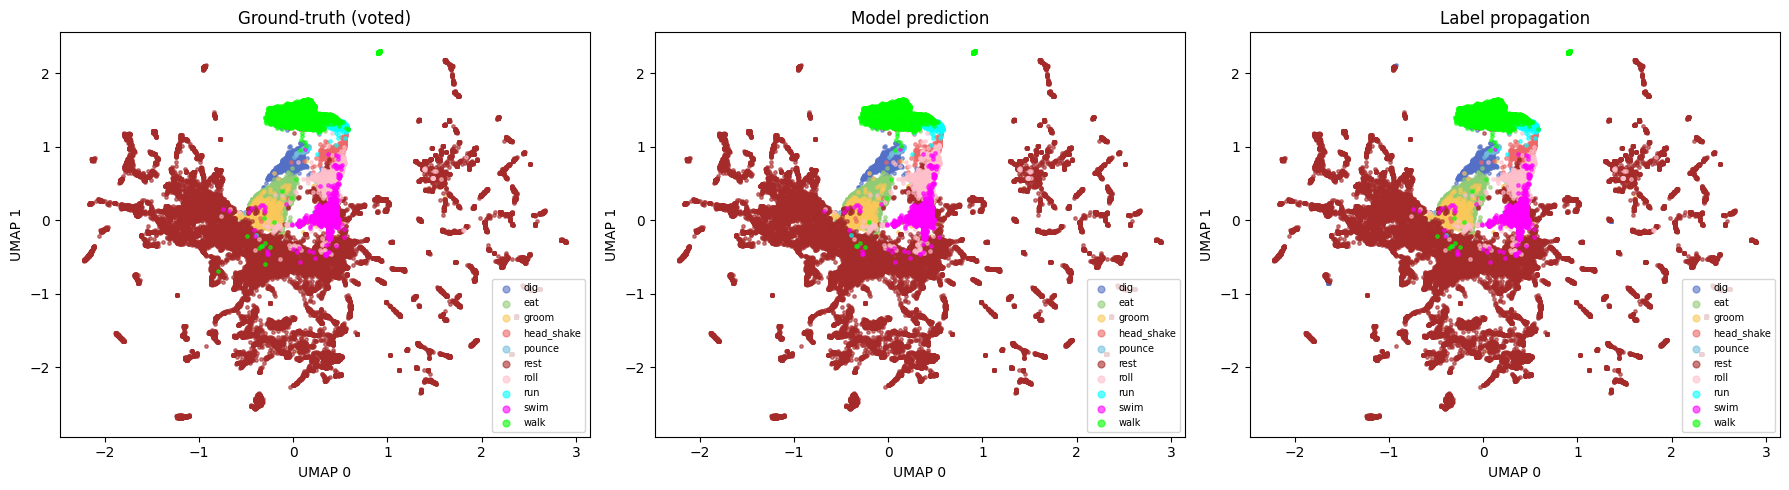

In [13]:
def scatter(ax, xy, labels, title):
    for lab in np.unique(labels):
        if lab < 0:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, c='lightgrey', alpha=0.3, label='unknown')
        else:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, alpha=0.6,
                       c=label_colors[int(lab)], label=labeldict_findstr.get(int(lab), str(lab)))
    ax.set_title(title); ax.set_xlabel('UMAP 0'); ax.set_ylabel('UMAP 1')
    ax.legend(markerscale=2, fontsize=7, loc='best')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter(axes[0], data_umap, all_labels, 'Ground-truth (voted)')
scatter(axes[1], data_umap, predictions, 'Model prediction')
scatter(axes[2], data_umap, propagated_labels, 'Label propagation')
plt.tight_layout(); plt.show()

### 5.1 时序标签图：真值(散点) vs 传播标签 / 模型预测(背景色块)

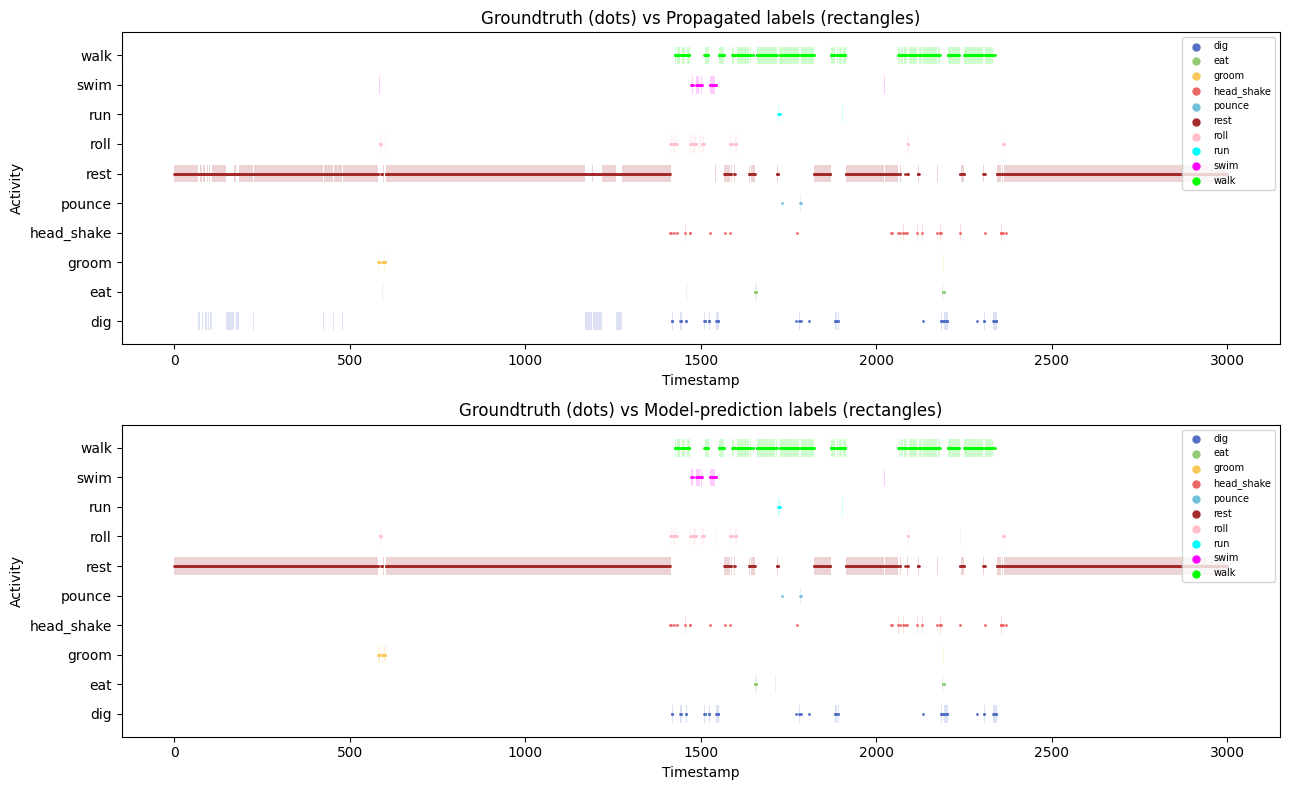

In [14]:
import matplotlib.patches as patches
new_len = len(data_b[startloc:endloc])
true_new = all_labels[-new_len:]
prop_new = propagated_labels[-new_len:]
pred_new = predictions[-new_len:]

def ts_plot(ax, overlay, title):
    for lab, name in labeldict_findstr.items():
        if lab >= 0:
            idx = np.where(true_new == lab)[0]
            ax.scatter(idx, [lab]*len(idx), s=1, color=label_colors[lab], label=name)
    for start in range(0, new_len):
        for lab in np.unique(overlay[start:start+1]):
            if lab >= 0 and lab in label_colors:
                ax.add_patch(patches.Rectangle((start, lab-0.3), 1, 0.6, linewidth=0,
                             facecolor=label_colors[int(lab)], alpha=0.2))
    ax.set_title(title); ax.set_xlabel('Timestamp'); ax.set_ylabel('Activity')
    ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
    ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
    ax.legend(markerscale=5, fontsize=7, loc='upper right')

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
ts_plot(axes[0], prop_new, 'Groundtruth (dots) vs Propagated labels (rectangles)')
ts_plot(axes[1], pred_new, 'Groundtruth (dots) vs Model-prediction labels (rectangles)')
plt.tight_layout(); plt.show()

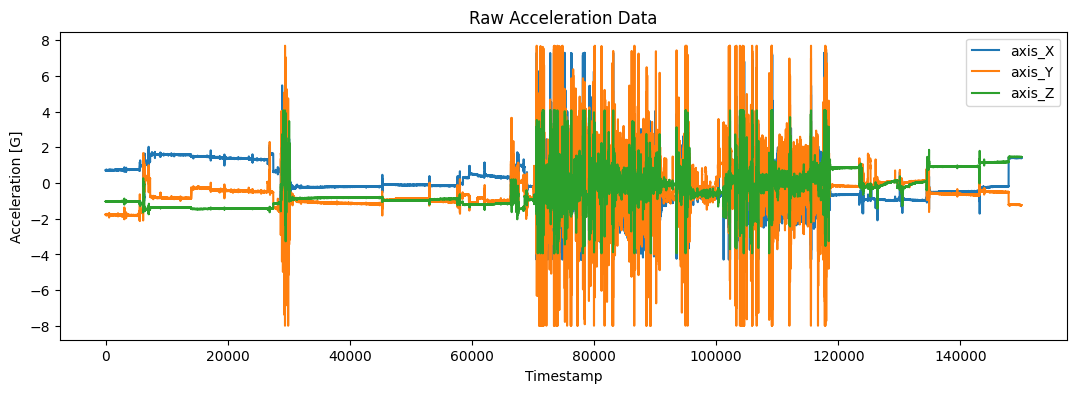

In [15]:
# 原始加速度三轴
plt.figure(figsize=(13,4))
acc = np.concatenate(data_b[startloc:endloc,:3,:].transpose(0,2,1), axis=0)
for i, name in enumerate(['axis_X','axis_Y','axis_Z']):
    plt.plot(acc[:,i], label=name)
plt.xlabel('Timestamp'); plt.ylabel('Acceleration [G]'); plt.title('Raw Acceleration Data')
plt.legend(loc='upper right'); plt.show()

## 6. 小结

- 与 umineko / turtle 复现 notebook 结构一致，仅替换数据集与模型（单加速度编码器、
  10 类、窗口 50、特征维 768）。
- 所有中间结果（数据形状、分布、逐轮指标、特征/UMAP/标签传播）均已内联保留。
- bear 类别极度不均衡（rest 占 ~77%，pounce/run 等极少），
  Macro-F1 受稀有类影响明显，Accuracy / Micro-F1 受多数类 rest 主导。